In [2]:
#Step 1: Load order-level data
import pandas as pd

# Reload raw tables
orders = pd.read_csv('../data/raw/olist_orders_dataset.csv')
order_items = pd.read_csv('../data/raw/olist_order_items_dataset.csv')
reviews = pd.read_csv('../data/raw/olist_order_reviews_dataset.csv')
products = pd.read_csv('../data/raw/olist_products_dataset.csv')

# Rebuild the merged order-level table (same logic as Phase 1)
df = orders.merge(reviews[['order_id', 'review_score']], on='order_id', how='left')
df = df.merge(order_items[['order_id', 'product_id']], on='order_id', how='left')
df = df.merge(products[['product_id', 'product_category_name']], on='product_id', how='left')

df['order_purchase_timestamp'] = pd.to_datetime(df['order_purchase_timestamp'])
df['order_delivered_customer_date'] = pd.to_datetime(df['order_delivered_customer_date'])
df['order_estimated_delivery_date'] = pd.to_datetime(df['order_estimated_delivery_date'])

df['delivery_delay_days'] = (df['order_delivered_customer_date'] - df['order_estimated_delivery_date']).dt.days
df['is_return_proxy'] = ((df['review_score'] <= 2) | (df['order_status'] == 'canceled')).astype(int)

# Drop duplicate rows from multi-item orders (one row per order, same fix as Phase 1)
df = df.drop_duplicates(subset='order_id').reset_index(drop=True)

print(df.shape)
df.head()

(99441, 13)


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,review_score,product_id,product_category_name,delivery_delay_days,is_return_proxy
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,4.0,87285b34884572647811a353c7ac498a,utilidades_domesticas,-8.0,0
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,4.0,595fac2a385ac33a80bd5114aec74eb8,perfumaria,-6.0,0
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,5.0,aa4383b373c6aca5d8797843e5594415,automotivo,-18.0,0
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,5.0,d0b61bfb1de832b15ba9d266ca96e5b0,pet_shop,-13.0,0
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,5.0,65266b2da20d04dbe00c5c2d3bb7859e,papelaria,-10.0,0


In [3]:
#Step 2: T-test — delivery delay vs. returns
from scipy import stats

# Drop rows with missing delay (undelivered orders won't have a delivery date)
delay_data = df.dropna(subset=['delivery_delay_days'])

returned_delay = delay_data[delay_data['is_return_proxy'] == 1]['delivery_delay_days']
not_returned_delay = delay_data[delay_data['is_return_proxy'] == 0]['delivery_delay_days']

print("Avg delay (returned):", returned_delay.mean())
print("Avg delay (not returned):", not_returned_delay.mean())

t_stat, p_value = stats.ttest_ind(returned_delay, not_returned_delay, equal_var=False)
print(f"\nT-statistic: {t_stat:.4f}")
print(f"P-value: {p_value:.6f}")

if p_value < 0.05:
    print("=> Statistically significant: delivery delay IS associated with returns")
else:
    print("=> Not statistically significant")

Avg delay (returned): -5.132985658409387
Avg delay (not returned): -12.85974538026697

T-statistic: 54.1716
P-value: 0.000000
=> Statistically significant: delivery delay IS associated with returns


In [4]:
# Compare average delay for returned vs not-returned, within each category
category_delay = df.dropna(subset=['delivery_delay_days', 'product_category_name']).groupby(
    ['product_category_name', 'is_return_proxy']
)['delivery_delay_days'].mean().unstack()

category_delay.columns = ['avg_delay_not_returned', 'avg_delay_returned']
category_delay['difference'] = category_delay['avg_delay_not_returned'] - category_delay['avg_delay_returned']

# Sort by how many orders each category has, to focus on categories with enough data to trust
category_counts = df['product_category_name'].value_counts()
category_delay = category_delay.loc[category_delay.index.isin(category_counts[category_counts > 500].index)]

category_delay.sort_values('difference', ascending=False)

,avg_delay_not_returned,avg_delay_returned,difference
product_category_name,,,
moveis_escritorio,-12.623975,-8.503704,-4.120272
pet_shop,-12.968149,-7.005714,-5.962434
eletroportateis,-14.511152,-8.529412,-5.981741
eletrodomesticos,-13.248876,-7.262500,-5.986376
utilidades_domesticas,-12.769170,-6.400612,-6.368558
telefonia,-12.151938,-5.588028,-6.563910
informatica_acessorios,-13.315969,-6.623794,-6.692175
cama_mesa_banho,-12.398450,-5.638402,-6.760047
moveis_decoracao,-13.296843,-6.463203,-6.833639


In [5]:
#Step 3 -> Chi-square test — product category vs. returns
from scipy.stats import chi2_contingency

# Only keep categories with reasonable sample size (500+ orders), same filter as before
cat_data = df.dropna(subset=['product_category_name'])
valid_categories = category_counts[category_counts > 500].index
cat_data = cat_data[cat_data['product_category_name'].isin(valid_categories)]

# Build a contingency table: rows = category, columns = return-proxy (0/1), values = order counts
contingency_table = pd.crosstab(cat_data['product_category_name'], cat_data['is_return_proxy'])

chi2_stat, p_value, dof, expected = chi2_contingency(contingency_table)

print(f"Chi-square statistic: {chi2_stat:.2f}")
print(f"P-value: {p_value:.6f}")
print(f"Degrees of freedom: {dof}")

if p_value < 0.05:
    print("=> Statistically significant: product category IS associated with returns")
else:
    print("=> Not statistically significant")

Chi-square statistic: 299.41
P-value: 0.000000
Degrees of freedom: 25
=> Statistically significant: product category IS associated with returns


In [6]:
category_return_rate = cat_data.groupby('product_category_name')['is_return_proxy'].mean().sort_values(ascending=False)

print("Top 5 highest return-rate categories:")
print(category_return_rate.head())

print("\nTop 5 lowest return-rate categories:")
print(category_return_rate.tail())

Top 5 highest return-rate categories:
product_category_name
moveis_escritorio         0.224506
cama_mesa_banho           0.163677
moveis_decoracao          0.162392
informatica_acessorios    0.159760
bebes                     0.154984
Name: is_return_proxy, dtype: float64

Top 5 lowest return-rate categories:
product_category_name
fashion_bolsas_e_acessorios    0.115426
pet_shop                       0.113850
papelaria                      0.112903
malas_acessorios               0.088954
livros_interesse_geral         0.082515
Name: is_return_proxy, dtype: float64


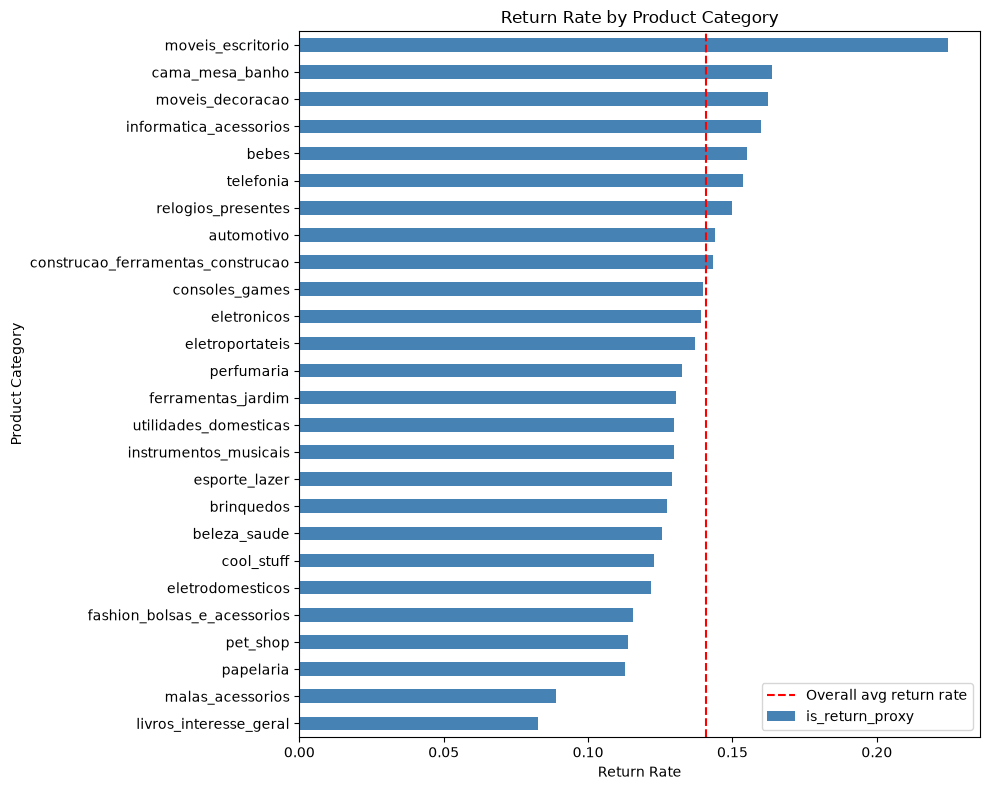

In [7]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))
category_return_rate.sort_values().plot(kind='barh', color='steelblue')
plt.axvline(cat_data['is_return_proxy'].mean(), color='red', linestyle='--', label='Overall avg return rate')
plt.title('Return Rate by Product Category')
plt.xlabel('Return Rate')
plt.ylabel('Product Category')
plt.legend()
plt.tight_layout()
plt.show()